In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
%pip install xgboost
from xgboost import XGBRegressor
#Step 2. Create a normal regression dataset

#Start with a simple relationship.

#Suppose:

#$$ Y = 3 + 2X_1 + 1.5X_2 - X_3 + \epsilon $$

#Generate 1,000 observations.
np.random.seed(42)

n = 1000

X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)

error = np.random.normal(0, 1, n)

Y = 3 + 2*X1 + 1.5*X2 - X3 + error

df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "Y": Y
})

df.head()
#Step 3. Split the data
X = df[["X1", "X2", "X3"]]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#80% training, 20% testing.
#Step 4. Create a function to compare models
def evaluate_models(X_train, X_test, y_train, y_test):

    models = {
        "OLS": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Huber": HuberRegressor(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, random_state=42
        ),
        "XGBoost": XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
    }

    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

    return pd.DataFrame(results)
results = evaluate_models(
    X_train, X_test, y_train, y_test
)

results

,Model,RMSE,MAE,R2
0,OLS,1.036938,0.827121,0.876029
1,Ridge,1.037339,0.827542,0.875933
2,Huber,1.037429,0.828090,0.875911
3,Random Forest,1.228379,0.956959,0.826028
4,XGBoost,1.132448,0.897738,0.852140


In [4]:
#generate non-linearity
def generate_nonlinear_data(
    n=1000,
    seed=42
):

    np.random.seed(seed)

    X1 = np.random.normal(0, 1, n)
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)

    error = np.random.normal(0, 1, n)

    Y = (
        3
        + 2 * (X1 ** 2)
        + 1.5 * X2
        - X3
        + error
    )

    return pd.DataFrame({
        "X1": X1,
        "X2": X2,
        "X3": X3,
        "Y": Y
    })

<ipython-input-5-eb4ac620c277>:18: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig(
<ipython-input-5-eb4ac620c277>:18: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig(


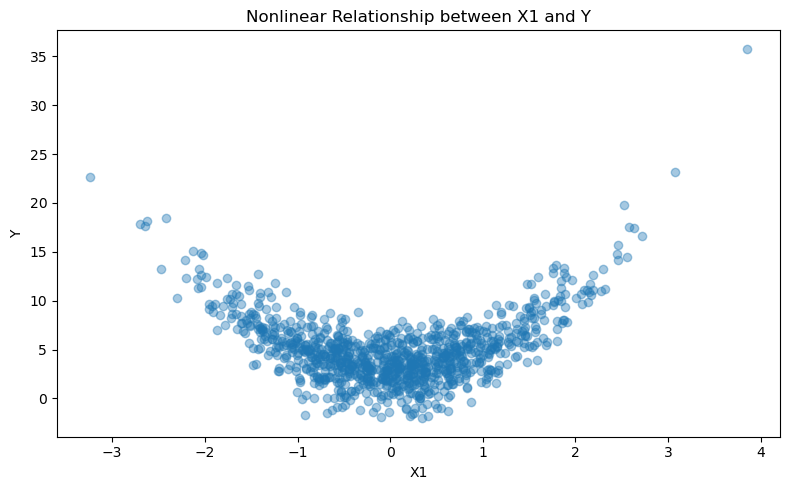

In [5]:
#Generate and visualize
data = generate_nonlinear_data()

plt.figure(figsize=(8, 5))

plt.scatter(
    data["X1"],
    data["Y"],
    alpha=0.4
)

plt.xlabel("X1")
plt.ylabel("Y")
plt.title("Nonlinear Relationship between X1 and Y")

plt.tight_layout()

plt.savefig(
    "../results/figures/nonlinearity_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
#Evaluate
X = data[["X1", "X2", "X3"]]
y = data["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

nonlinear_results = evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test
)

nonlinear_results

,Model,RMSE,MAE,R2
0,OLS,3.251633,2.062942,0.321600
1,Ridge,3.251994,2.063085,0.321449
2,Huber,3.299538,1.952120,0.301463
3,Random Forest,1.795850,1.060234,0.793070
4,XGBoost,1.710340,0.965401,0.812307


In [8]:
#save
nonlinear_results.to_csv(
    "../results/tables/nonlinearity_results.csv",
    index=False
)

<ipython-input-9-882fa0446a3c>:16: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig(
<ipython-input-9-882fa0446a3c>:16: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig(


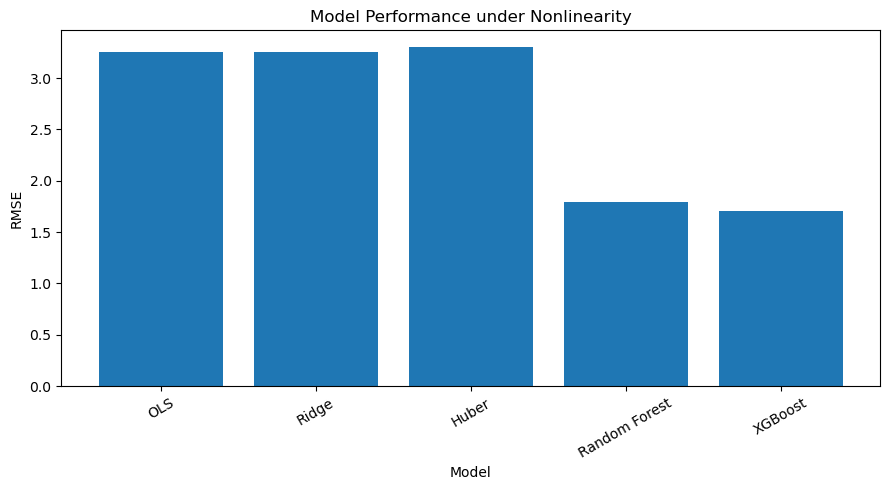

In [9]:
plt.figure(figsize=(9, 5))

plt.bar(
    nonlinear_results["Model"],
    nonlinear_results["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Performance under Nonlinearity")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../results/figures/nonlinearity_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()